# Figure S11A-C. PHIST host benchmarking

In [48]:
### Load packages
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import glob
import gzip
plt.rcParams.update({'font.size': 14})

In [ ]:
### Download mOTUs-DB isolates (no already in HRGM2 or HROM)
# !wget https://zenodo.org/records/13325008/files/Supplementary_Table_1.tsv.gz?download=1 -O Supplementary_Table_1.tsv.gz
# !wget https://zenodo.org/records/13325008/files/Supplementary_Table_3.tsv.gz?download=1 -O Supplementary_Table_3.tsv.gz
# !wget https://zenodo.org/records/13325008/files/Supplementary_Table_4.tsv.gz?download=1 -O Supplementary_Table_4.tsv.gz
# downloaded mOTUs-DB metadata by clicking "Export Metadata > All" all here: https://motus-db.org/genome-cols

### Benchmark using UHGV

In [2]:
def _extract_rank_token(taxonomy, rank):
    if taxonomy is None:
        return None
    for token in str(taxonomy).split(';'):
        token = token.strip()
        if token.startswith(f'{rank}__'):
            value = token.split('__', 1)[1].strip()
            if value:
                return token
            return None
    return None


def _species_genus_family_consensus(taxonomy_list, min_agreement=0.7):
    """Return all passing consensus hits across species, genus, and family."""
    taxonomies = [t for t in taxonomy_list if t is not None and str(t).strip()]
    total = len(taxonomies)
    if total == 0:
        return []

    rank_full = {
        's': 'species',
        'g': 'genus',
        'f': 'family',
    }

    results = []
    for rank in ['s', 'g', 'f']:
        counts = {}
        for taxonomy in taxonomies:
            token = _extract_rank_token(taxonomy, rank)
            if token is None:
                continue
            counts[token] = counts.get(token, 0) + 1

        if not counts:
            continue

        top_token, top_count = max(counts.items(), key=lambda x: x[1])
        agreement = top_count / total
        if agreement >= min_agreement:
            results.append({
                'rank': rank_full[rank],
                'agreement': agreement,
                'consensus_taxonomy': top_token,
            })

    return results


meta_df_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/uhbdb' + "/*/*/*.metadata.tsv.gz"):
    # load host info
    df = pl.read_csv(
        file, separator='\t'
    )
    if len(df.columns) == 15:
        df = df.with_columns([
            pl.col('genome_id').alias('cluster')
        ])
    meta_df_lst.append(df)
metadata = pl.concat(meta_df_lst)

# load phist output
virus_dict = {}
phist_lst = []

line_num = 0
for file in glob.glob('../figure_1/tmp/2026-03-11/phist/phist/uhbdb/chunk_*/chunk_*.phist.min.csv.gz'):
    with gzip.open(file, 'rt') as f_in:
        for line in f_in:
            if line.startswith('kmer-length'):
                split = line.strip().split(',')[1:]
                for index, virus in enumerate(split):
                    virus_dict[index] = virus
            elif line.startswith('query-samples'):
                continue
            else:
                split = line.strip().split(',')
                genome_id_1 = split[0]
                genome_id = genome_id_1.split('.f')[0]
                for hit in split[1:-1]:
                    if ':' not in hit:
                        continue
                    # print(hit.split(':'))
                    index, perc_kmers = hit.split(':')
                    if float(perc_kmers) >= 0.2:
                        phist_lst.append({
                            'Target id': virus_dict[int(index)-1],
                            'Genome': genome_id,
                            'Containment': perc_kmers
                        })
                    else:
                        continue
            line_num += 1
            if line_num % 1000000 == 0:
                print(f'Processed {line_num} lines')

phist_hits = (
    pl.DataFrame(phist_lst)
        .join(metadata, left_on='Genome', right_on='genome_id', how='inner')
)

phist_host = (
    phist_hits
        .group_by('Target id')
        .agg([
            pl.len().alias('total_connections'),
            pl.col('taxonomy').alias('taxonomy_hits'),
        ])
        .with_columns([
            pl.col('taxonomy_hits').map_elements(
                lambda values: _species_genus_family_consensus(values, min_agreement=0.7),
                return_dtype=pl.List(
                    pl.Struct([
                        pl.Field('rank', pl.String),
                        pl.Field('agreement', pl.Float64),
                        pl.Field('consensus_taxonomy', pl.String),
                    ])
                )
            ).alias('consensus')
        ])
        .explode('consensus')
        .unnest('consensus')
        .drop('taxonomy_hits')
)

Processed 1000000 lines


In [12]:
phist_hits_2 = phist_hits[['Target id', 'Genome', 'Containment', 'genome', 'taxonomy']]

phist_lst = []
for i in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    phist_lst.append(
        phist_hits_2
            .with_columns([
                pl.col('Containment').cast(pl.Float32),
            ])
            .filter(pl.col('Containment') >= i)
            .group_by('Target id')
            .agg([
                pl.len().alias('total_connections'),
                pl.col('taxonomy').alias('taxonomy_hits'),
            ])
            .with_columns([
                pl.col('taxonomy_hits').map_elements(
                    lambda values: _species_genus_family_consensus(values, min_agreement=0.7),
                    return_dtype=pl.List(
                        pl.Struct([
                            pl.Field('rank', pl.String),
                            pl.Field('agreement', pl.Float64),
                            pl.Field('consensus_taxonomy', pl.String)
                        ])
                    )
                ).alias('consensus'),
                pl.lit(i).alias('containment_threshold')
            ])
            .explode('consensus')
            .unnest('consensus')
            .drop('taxonomy_hits')
    )
phist_hits_thresholded = pl.concat(phist_lst)

In [18]:
### load motus metadata and join with UHGV phist results

# !wget https://sunagawalab.ethz.ch/share/MOTUS/database/4.0/data/mOTUs4.0_genome-metadata-20250702.alpha.tsv.gz

motus_meta = pl.read_csv('mOTUs4.0_genome-metadata-20250702.alpha.tsv.gz', separator='\t', columns=['GENOME', 'SPECIES', 'GENUS', 'FAMILY', 'ORDER', 'CLASS', 'PHYLUM'])

# load mapping file
mapping = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-11_outputs/rename/hq_hc_viruses/hq_hc_viruses.id_mapping.tsv.gz', separator='\t', ignore_errors=True, has_header=False)
    .with_columns([
        pl.col('column_1').str.replace(r'\|provirus.*', '')
    ])
)

# join with host predictions
uhvdb_host_predictions = (
    phist_hits_thresholded
        .join(mapping, left_on='Target id', right_on='column_2', how='inner')
)

Target id,total_connections,rank,agreement,consensus_taxonomy,containment_threshold,column_1
str,u32,str,f64,str,f64,str
"""UHVDB-69814""",264,null,null,null,0.2,"""UHGV-0251839"""
"""UHVDB-99138""",3247,"""species""",0.947952,"""s__Klebsiella pneumoniae""",0.2,"""UHGV-1358368"""


In [17]:
### analyze UHGV's original phist annotations
hq_votus = (
    pl.read_csv('../figure_s6/votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'kmers_total_connections', 'kmers_host_agreement', 'kmers_host_lineage_gtdb_r207'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .with_columns(pl.col('kmers_total_connections').cast(pl.Float64))
        .with_columns(pl.col('kmers_host_agreement').cast(pl.Float64))
        .with_columns([
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_species'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_genus'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_family'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_order'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_class'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_phylum')
        ])
)

# count UHGV PHIST assignments at each rank
print("Total UHGV HQ vOTUs:", hq_votus['uhgv_genome'].n_unique())
print("Number of UHGV HQ vOTUs with predicted hosts from kmer method:", hq_votus.filter(pl.col('kmers_total_connections') > 0)['uhgv_genome'].n_unique())
print("Number with species-level assignments:", hq_votus.filter(pl.col('host_species').is_not_null())['uhgv_genome'].n_unique())
print("Number with genus-level assignments:", hq_votus.filter(pl.col('host_genus').is_not_null())['uhgv_genome'].n_unique())
print("Number with family-level assignments:", hq_votus.filter(pl.col('host_family').is_not_null())['uhgv_genome'].n_unique())
print("Number with order-level assignments:", hq_votus.filter(pl.col('host_order').is_not_null())['uhgv_genome'].n_unique())
print("Number with class-level assignments:", hq_votus.filter(pl.col('host_class').is_not_null())['uhgv_genome'].n_unique())
print("Number with phylum-level assignments:", hq_votus.filter(pl.col('host_phylum').is_not_null())['uhgv_genome'].n_unique())

Total UHGV HQ vOTUs: 57514
Number of UHGV HQ vOTUs with predicted hosts from kmer method: 34222
Number with species-level assignments: 22872
Number with genus-level assignments: 27402
Number with family-level assignments: 30662
Number with order-level assignments: 31344
Number with class-level assignments: 32156
Number with phylum-level assignments: 34222


In [21]:
uhvdb_host_predictions.head(2)

Target id,total_connections,rank,agreement,consensus_taxonomy,containment_threshold,column_1
str,u32,str,f64,str,f64,str
"""UHVDB-69814""",264,null,null,null,0.2,"""UHGV-0251839"""
"""UHVDB-99138""",3247,"""species""",0.947952,"""s__Klebsiella pneumoniae""",0.2,"""UHGV-1358368"""


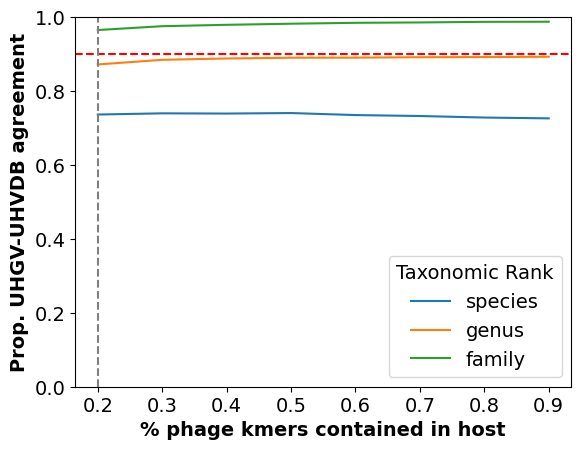

In [50]:
### Compare agreement between original UHGV phist annotations and new annotations
### using varying % kmer containment thresholds
recalls = []
precisions = []
f1s = []
num_ks = []
percents = []
props = []
ranks = []

for i in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    for rank in ['species', 'genus', 'family']:#, 'phylum', 'order', 'class', 'phylum']:
        uhgv_phist_annotated = (
            uhvdb_host_predictions
                .filter(pl.col('containment_threshold') == i)
                .filter(pl.col('rank') == rank)
                .with_columns([
                    pl.col('consensus_taxonomy').str.split('__').list[1].alias(f'consensus_{rank}'),
                ])
        )

        for num_k in [1]:
            # identify UHVDB agreement with UHGV phist assignments
            uhgv_uhvdb_join = (
                hq_votus
                    .filter(pl.col(f'host_{rank}').is_not_null())
                    # .with_columns(pl.col('host_phylum').str.split('_').list[0])
                    .join(uhgv_phist_annotated, left_on='uhgv_genome', right_on='column_1', how='left')
                    .sort(pl.col('kmers_total_connections'))
            )

            tp = uhgv_uhvdb_join.filter(pl.col(f'host_{rank}') == pl.col(f'consensus_{rank}')).height
            fp = uhgv_uhvdb_join.filter((pl.col(f'host_{rank}') != pl.col(f'consensus_{rank}')) & (~pl.col(f'consensus_{rank}').is_null())).height
            fn = uhgv_uhvdb_join.filter(pl.col(f'consensus_{rank}').is_null()).height

            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            recalls.append(recall)
            precisions.append(precision)
            f1s.append(f1)
            num_ks.append(num_k)
            percents.append(i)
            props.append(uhgv_phist_annotated.height / hq_votus['uhgv_genome'].n_unique())
            ranks.append(rank)

### plot UHGV original vs new phist agreement (% kmer cutoffs)
precision_df = pl.DataFrame({
    'rank': ranks,
    'num_kmers': num_ks,
    'percents': percents,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props
})

# plot results as a seaborn lineplot
sns.lineplot(data=precision_df, x='percents', y='precision', hue='rank')
plt.xlabel('% phage kmers contained in host', fontdict={'fontweight': 'bold'})
plt.ylabel('Prop. UHGV-UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=0.2, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()

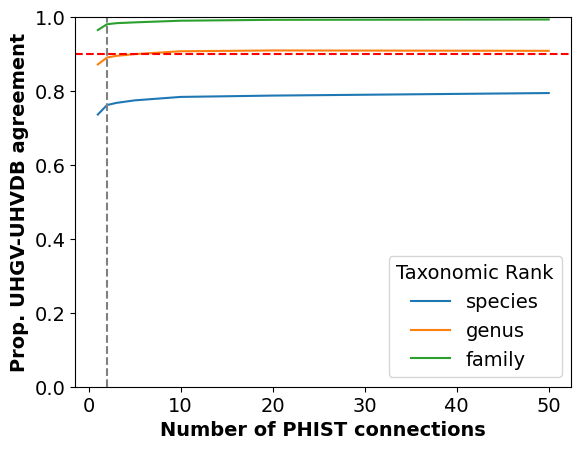

In [ ]:
### Compare agreement between original UHGV phist annotations and new annotations
### using a fixed 20% kmer containment threshold and varying minimum host-genome connections
recalls = []
precisions = []
f1s = []
num_ks = []
min_connections = []
props = []
ranks = []

for rank in ['species', 'genus', 'family']:#, 'phylum', 'order', 'class', 'phylum']:
    uhgv_phist_annotated = (
        uhvdb_host_predictions
            .filter(pl.col('containment_threshold') == 0.2)
            .filter(pl.col('rank') == rank)
            .with_columns([
                pl.col('consensus_taxonomy').str.split('__').list[1].alias(f'consensus_{rank}'),
            ])
    )

    for min_conn in [1, 2, 3, 5, 10, 20, 50]:
        # identify UHVDB agreement with UHGV phist assignments
        uhgv_uhvdb_join = (
            hq_votus
                .filter(pl.col(f'host_{rank}').is_not_null())
                # .with_columns(pl.col('host_phylum').str.split('_').list[0])
                .join(uhgv_phist_annotated, left_on='uhgv_genome', right_on='column_1', how='left')
                .sort(pl.col('kmers_total_connections'))
        )

        tp = uhgv_uhvdb_join.filter((pl.col(f'host_{rank}') == pl.col(f'consensus_{rank}')) & (pl.col('total_connections') >= min_conn)).height
        fp = uhgv_uhvdb_join.filter((pl.col(f'host_{rank}') != pl.col(f'consensus_{rank}')) & (~pl.col(f'consensus_{rank}').is_null()) & (pl.col('total_connections') >= min_conn)).height
        fn = uhgv_uhvdb_join.filter((pl.col(f'consensus_{rank}').is_null()) | (pl.col('total_connections') < min_conn)).height

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
        num_ks.append(min_conn)
        min_connections.append(min_conn)
        props.append(
            uhgv_phist_annotated.filter(pl.col('total_connections') >= min_conn).height / hq_votus['uhgv_genome'].n_unique()
        )
        ranks.append(rank)

# Backward-compatible alias for downstream cells that still expect `percents`
percents = min_connections

### plot UHGV original vs new phist agreement (minimum host-genome connections at fixed 20% containment)
precision_df = pl.DataFrame({
    'rank': ranks,
    'num_kmers': num_ks,
    'percents': percents,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props
})

# plot results as a seaborn lineplot
sns.lineplot(data=precision_df, x='percents', y='precision', hue='rank')
plt.xlabel('Number of PHIST connections', fontdict={'fontweight': 'bold'})
plt.ylabel('Prop. UHGV-UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=2, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()

In [38]:
### Identify number of HQ vOTUs run through both methods
both_methods = set(
    mapping.join(hq_votus, left_on='column_1', right_on='uhgv_genome', how='inner')
        ['column_1']
)
print("Number of HQ vOTUs run through both methods:", len(both_methods))

Number of HQ vOTUs run through both methods: 51339


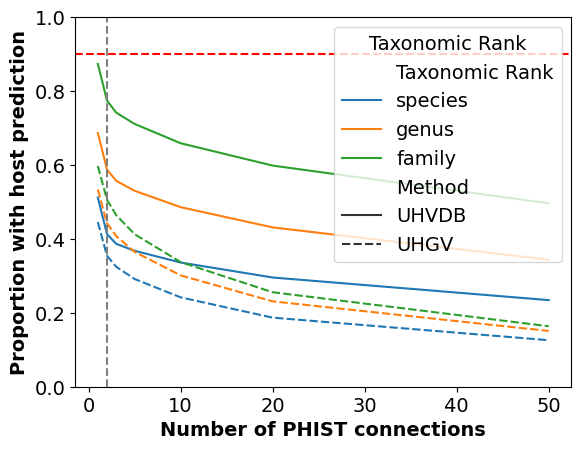

In [58]:
### Identify proportion of genomes annotated at each rank by number of connections
connection_thresholds = [1, 2, 3, 5, 10, 20, 50]

props = []
methods = []
num_connections = []
ranks = []
num_annotated = []
num_total = []

# dataset-specific denominators
hq_total = hq_votus.filter(pl.col('uhgv_genome').is_in(both_methods)).select('uhgv_genome').unique().height
uhvdb_total = (
    uhvdb_host_predictions
        .filter(pl.col('containment_threshold') == 0.2)
        .select('column_1')
        .unique()
        .height
)

for rank in ['species', 'genus', 'family']:
    for n_conn in connection_thresholds:
        # New method annotations (UHVDB PHIST-derived), fixed at 20% containment
        uhvdb_annotated = (
            uhvdb_host_predictions
                .filter(pl.col('containment_threshold') == 0.2)
                .filter(pl.col('rank') == rank)
                .filter(pl.col('total_connections') >= n_conn)
                .select('column_1')
                .unique()
                .height
        )
        props.append(uhvdb_annotated / uhvdb_total if uhvdb_total > 0 else 0)
        methods.append('UHVDB')
        num_connections.append(n_conn)
        ranks.append(rank)
        num_annotated.append(uhvdb_annotated)
        num_total.append(uhvdb_total)

        # Original UHGV annotations
        uhgv_old = (
            hq_votus
                .filter(pl.col(f'host_{rank}').is_not_null())
                .filter(pl.col('kmers_total_connections') >= n_conn)
                .select('uhgv_genome')
                .unique()
                .height
        )
        props.append(uhgv_old / hq_total if hq_total > 0 else 0)
        methods.append('UHGV')
        num_connections.append(n_conn)
        ranks.append(rank)
        num_annotated.append(uhgv_old)
        num_total.append(hq_total)

# create a dataframe with the results
annotation_rate_df = pl.DataFrame({
    'Taxonomic Rank': ranks,
    'num_connections': num_connections,
    'proportion_annotated': props,
    'Method': methods,
    'num_annotated': num_annotated,
    'num_total': num_total
})

# plot results
sns.lineplot(
    data=annotation_rate_df,
    x='num_connections',
    y='proportion_annotated',
    hue='Taxonomic Rank',
    style='Method'
)
plt.xlabel('Number of PHIST connections', fontdict={'fontweight': 'bold'})
plt.ylabel('Proportion with host prediction', fontdict={'fontweight': 'bold'})
plt.ylim(0, 1)
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=2, color='grey', linestyle='--')
plt.legend(title='Taxonomic Rank', loc='upper right') 
plt.show()